In [4]:
# from pycolvars import pmf
import glob
import os
import re

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

In [3]:
import MDAnalysis as mda

/global/cfs/cdirs/m4248/xiaoxusr/miniconda3/envs/sea_urchin/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions

In [16]:
CVs = ["Distance Along Arm", "Na_glyme_O CN", "Tetramer_TFSI_O CN"]

In [6]:
def pmf_overtime_multiple(path, time_list, con_steps=10):
    # figs, axes = plt.subplots(3,len(time_list)//3+1,figsize=(10,10))
    # axes = axes.flatten()
    for t in time_list:
        obj = pmf.MultipleReplica(pmf_path=path,
                                  pmf_name=f"colvar.out.{t}.pmf")
        obj.plot_colvars_data(con_steps=con_steps)
        plt.title(f"colvar.out.{t}.pmf")

In [7]:
def pmf_overtime_single(path, time_list, con_steps=10):
    # figs, axes = plt.subplots(3,len(time_list)//3+1,figsize=(10,10))
    # axes = axes.flatten()
    for t in time_list:
        obj = pmf.SingleReplica(pmf_path=path,
                                  pmf_name=f"colvar.out.{t}.pmf")
        obj.plot_colvars_data(con_steps=con_steps)
        plt.title(f"colvar.out.{t}.pmf")

In [8]:
def read_data(path):
    data = pd.read_csv(path, comment='#', sep='\s+', header=None)
    if data.iloc[-1].isnull().any():
        data = data.iloc[:-1]
    return data

In [19]:
def plot_traj_overtime_all(base_path, CVs):
    
    colvar_data_all = [] 
    for i in range(1,11):
        replica_dir = os.path.join(base_path, f"{str(i).zfill(2)}_IDNR")
        colvar_file = os.path.join(replica_dir, "colvar.out.colvars.traj")
        if os.path.isfile(colvar_file): 
            colvar_data = read_data(colvar_file)
            # colvar_data["replica_id"] = i 
        colvar_data_all.append(colvar_data)
    figs, axes = plt.subplots(4,1, figsize=(15,15))
    axes = axes.flatten()
    # Plot the coordination number over time
    # axes[0].plot(data[0], data[1], label='Coordination Number Li-O')
    for i in range(10):
        data = colvar_data_all[i]
        axes[0].plot(data.iloc[40000:,0], data.iloc[40000:,1], label=f'{CVs[0]} Replica {i+1}')
        axes[1].plot(data.iloc[40000:,0], data.iloc[40000:,2], label=f'{CVs[0]} Replica {i+1}')
        axes[2].plot(data.iloc[40000:,0], data.iloc[40000:,3], label=f'{CVs[0]} Replica {i+1}')
        axes[3].plot(data.iloc[40000:,0], data.iloc[40000:,4], label=f'Biased potential applied Replica {i+1}')
        # axes[2].set_xlabel('Time Step')
        # axes.set_ylabel('Biased potential applied')
        figs.suptitle('Collective Variables and Biased potential applied Over Time', fontsize=20)
        for ax in axes:
            ax.legend()
            ax.grid(True)
            # ax.set_xlabel('CN')

In [12]:
def plot_cv_histogram_full(base_path,CVs):

    # Assuming colvars.traj is formatted with spaces as delimiters and has a header row
    colvar_data_all = [] 
    for i in range(1,11):
        replica_dir = os.path.join(base_path, f"{str(i).zfill(2)}_IDNR")
        colvar_file = os.path.join(replica_dir, "colvar.out.colvars.traj")
        if os.path.isfile(colvar_file): 
            colvar_data = read_data(colvar_file) 
        colvar_data_all.append(colvar_data)
    data = pd.concat(colvar_data_all)
    figs, axes = plt.subplots(3,1, figsize=(8,6))
    # axes = axes.flatten()
    # Plot the coordination number over time
    axes[0].hist(data.iloc[:,1], bins=15, label=CVs[0])
    axes[1].hist(data.iloc[:,2], bins=15, label=CVs[1])
    axes[2].hist(data.iloc[:,3], bins=15, label=CVs[2])
    
    figs.suptitle('Collective Variables Histogram', fontsize=20)
    for ax in axes:
        ax.legend()
        ax.grid(True)
        # ax.set_xlabel('CN')

In [13]:
def plot_sliced_data_overtime(file_list,locs,axis):
    import os
    from tqdm import tqdm
    for f in tqdm(f_list[-15:]):
        # print(f)
        f_path = os.path.join("/",*(f.split("/")[:-1]))
        # print(f_path)
        f_name =  f.split("/")[-1]
        obj = pmf.SingleReplica(pmf_path=f_path, 
                                pmf_name=f_name)
        sliced_data = obj.get_1D_slice(locs=locs, axis=axis);
        plt.plot(sliced_data[0][0], label=f"{f_name}")
        plt.legend()
    

1. check equilibration

In [14]:
base_path="/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/metadynamics/glyme_tetramer_2_1_fix_momentum/meta_09302025/"

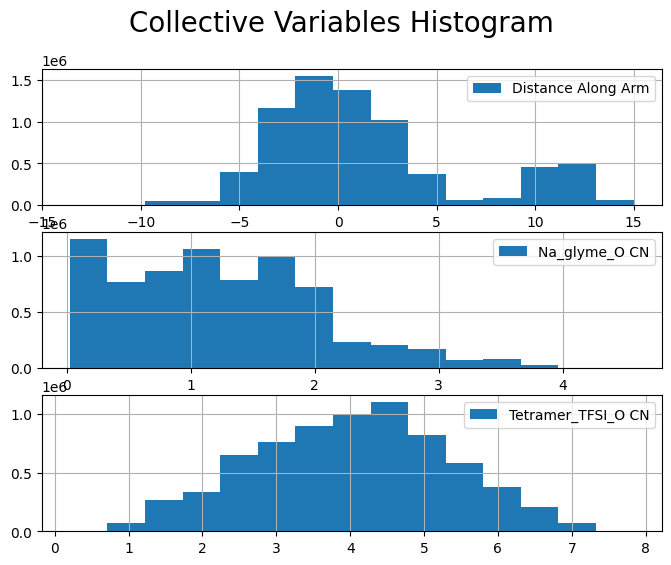

In [17]:
plot_cv_histogram_full(base_path, CVs)

/global/cfs/cdirs/m4248/xiaoxusr/miniconda3/envs/sea_urchin/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/global/cfs/cdirs/m4248/xiaoxusr/miniconda3/envs/sea_urchin/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


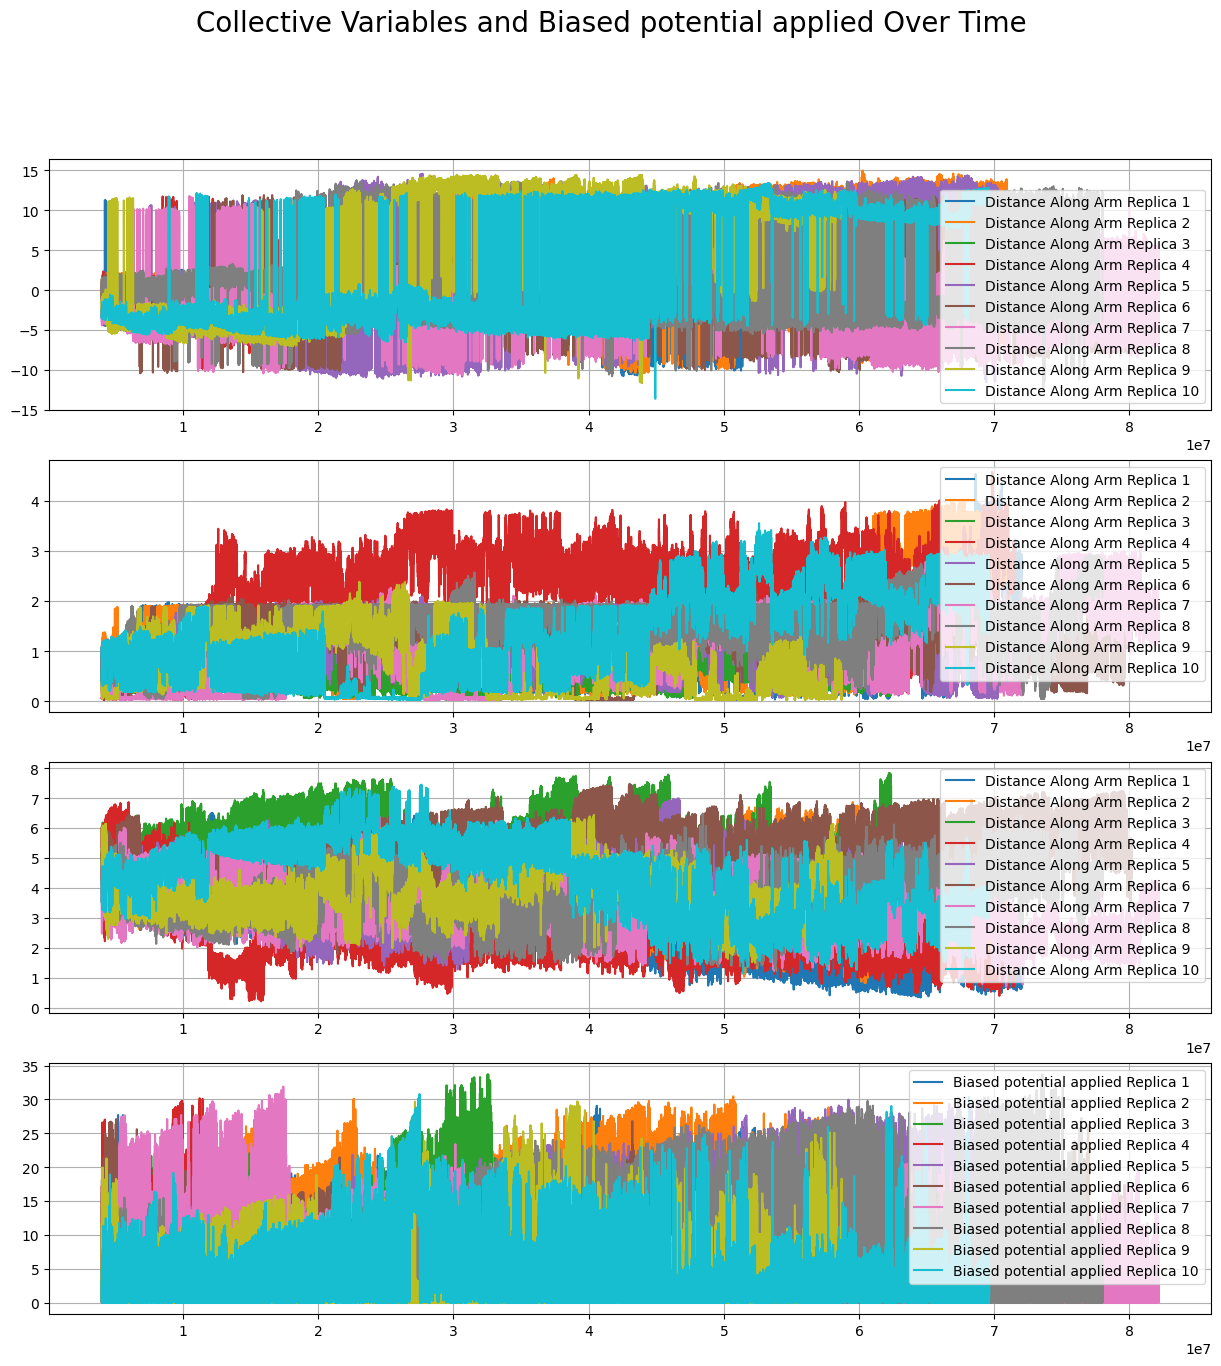

In [21]:
plot_traj_overtime_all(base_path, CVs)

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata


# Load data
data = np.loadtxt('/global/cfs/cdirs/m4248/xiaoxusr/na_conductor/tetramer_glymes/metadynamics/glyme_tetramer_8_1_fix_momentum/meta/10_IDNR/colvar.out.pmf')


x, y, z, pmf_kcal = data[:,0], data[:,1], data[:,2], data[:,3]   # pycolvars is typically kcal/mol
pmf_kT = pmf_kcal / 0.592    # convert to kT at 298 K if you want that unit

# Build unique sorted axes
ux = np.unique(x)
uy = np.unique(y)
uz = np.unique(z)

# Sanity check: should match total points
assert ux.size * uy.size * uz.size == pmf_kT.size, (
    f"Grid dims {ux.size}x{uy.size}x{uz.size} != {pmf_kT.size}"
)

# Map each point to its grid index
ix = np.searchsorted(ux, x)
iy = np.searchsorted(uy, y)
iz = np.searchsorted(uz, z)

# Allocate and fill a 3D array [z, y, x]
pmf3d = np.full((uz.size, uy.size, ux.size), np.nan)
pmf3d[iz, iy, ix] = pmf_kT   # now it's on a regular grid without interpolation


In [6]:
# Set font sizes and general styles
plt.rcParams.update({
    'font.size': 16,              # Set default font size
    'axes.labelweight': 'bold',   # Bold labels
    'axes.linewidth': 1.5,        # Axis line width
    'grid.color': '#888888',      # Gray grid lines
    'grid.linestyle': '--',       # Dashed grid lines
    'grid.linewidth': 0.5,        # Grid line width
    'xtick.major.size': 5,        # Major tick size
    'ytick.major.size': 5         # Major tick size
})


In [7]:
def _to_kT(pmf, from_units="kcal/mol", T=298.15):
    """Convert PMF to kT if needed. 1 kT ≈ 0.0019872041*T kcal/mol."""
    if from_units is None or from_units.lower() in ["kt", "kbt", "k_b*t"]:
        return pmf
    if from_units.lower() in ["kcal", "kcal/mol", "kcal_per_mol"]:
        kT_kcal = 0.0019872041 * T
        return pmf / kT_kcal
    raise ValueError(f"Unrecognized units: {from_units}")

def build_pmf_grid(x, y, z, pmf, units="kcal/mol", T=298.15):
    """
    Map scattered (x,y,z,pmf) onto a regular 3D grid without interpolation.
    Returns pmf3d (shape: [nz, ny, nx]) and axis arrays ux, uy, uz.
    """
    pmf_kT = _to_kT(np.asarray(pmf), from_units=units, T=T)
    x, y, z = np.asarray(x), np.asarray(y), np.asarray(z)
    ux, uy, uz = np.unique(x), np.unique(y), np.unique(z)

    if ux.size * uy.size * uz.size != pmf_kT.size:
        raise ValueError(f"Inconsistent grid: {ux.size}*{uy.size}*{uz.size} != {pmf_kT.size}")

    ix, iy, iz = np.searchsorted(ux, x), np.searchsorted(uy, y), np.searchsorted(uz, z)

    pmf3d = np.full((uz.size, uy.size, ux.size), np.nan, dtype=float) # the way to put in the data so you can search by data[x][y][z]
    pmf3d[iz, iy, ix] = pmf_kT
    return pmf3d, ux, uy, uz

def idx_from_value(axis_vals, target):
    """Return index of axis_vals closest to target value."""
    axis_vals = np.asarray(axis_vals)
    return int(np.nanargmin(np.abs(axis_vals - target)))

def slice_projection(pmf3d, ux, uy, uz, labels=None, *, x_idx=None, y_idx=None, z_idx=None):
    """
    Get a 2D slice by fixing exactly one index.
    labels: dict with keys {"x","y","z"} for nicer axis names.
    """
    if labels is None:
        labels = {"x": "CV1", "y": "CV2", "z": "CV3"}

    fixed = [i is not None for i in (x_idx, y_idx, z_idx)]
    if sum(fixed) != 1:
        raise ValueError("Provide exactly one of x_idx, y_idx, or z_idx.")

    nz, ny, nx = pmf3d.shape

    if z_idx is not None:
        if not (0 <= z_idx < nz): raise IndexError("z_idx out of range")
        slc = pmf3d[z_idx, :, :]
        return slc, ux, uy, labels["x"], labels["y"], f"{labels['z']} ≈ {uz[z_idx]:.6g}"

    if y_idx is not None:
        if not (0 <= y_idx < ny): raise IndexError("y_idx out of range")
        slc = pmf3d[:, y_idx, :]
        return slc, ux, uz, labels["x"], labels["z"], f"{labels['y']} ≈ {uy[y_idx]:.6g}"

    if x_idx is not None:
        if not (0 <= x_idx < nx): raise IndexError("x_idx out of range")
        slc = pmf3d[:, :, x_idx]
        return slc, uy, uz, labels["y"], labels["z"], f"{labels['x']} ≈ {ux[x_idx]:.6g}"

def plot_slice(
    ax, slc2d, ax_x, ax_y,
    xlabel="CV1", ylabel="CV2", title_suffix=None,
    vmin=None, vmax=None, cmap="viridis",
    grid=True, contour=True, n_levels=10
):
    slc = np.asarray(slc2d)
    ax_x = np.asarray(ax_x)
    ax_y = np.asarray(ax_y)

    vmin = np.nanmin(slc) if vmin is None else vmin
    vmax = np.nanmax(slc) if vmax is None else vmax

    extent = (ax_x.min(), ax_x.max(), ax_y.min(), ax_y.max())
    im = ax.imshow(slc, extent=extent, origin="lower", aspect="auto",
                   vmin=vmin, vmax=vmax, cmap=cmap)
    cbar = plt.colorbar(im)
    
    # Optional: Add a label to the colorbar
    cbar.set_label('Free Energy (kbT)')
    if contour:
        slc_masked = np.ma.masked_invalid(slc)
        X, Y = np.meshgrid(ax_x, ax_y)
        levels = np.linspace(vmin, vmax, n_levels)
        ax.contour(X, Y, slc_masked, levels=levels, colors="black", linewidths=0.75)

    ax.set_xlabel(xlabel, fontsize=14, weight="bold")
    ax.set_ylabel(ylabel, fontsize=14, weight="bold")
    if title_suffix:
        ax.set_title(title_suffix, fontsize=14, weight="bold")
    if grid:
        ax.grid(True, alpha=0.4, ls="--")

    return im

In [8]:
def plot_three_projections(
    pmf3d, ux, uy, uz, *,
    x_idx=None, y_idx=None, z_idx=None,
    labels=None,
    cmap="viridis", contour=True, n_levels=12,
    share_limits="global"  # "global" or "local"
):
    """
    Plot XY (at z_idx), XZ (at y_idx), YZ (at x_idx) with a shared colorbar.
    pmf3d shape: (nz, ny, nx) = [z, y, x]; ux, uy, uz are axis values.
    labels: dict {"x": "...", "y": "...", "z": "..."} for axis names.
    """
    nz, ny, nx = pmf3d.shape
    if labels is None:
        labels = {"x": "CV1", "y": "CV2", "z": "CV3"}

    # Defaults if not provided
    if z_idx is None: z_idx = nz // 2
    if y_idx is None: y_idx = ny // 2
    if x_idx is None: x_idx = nx // 2

    # Extract slices
    slc_xy = pmf3d[z_idx, :, :]     # (ny, nx)   axes: x=ux, y=uy
    slc_xz = pmf3d[:, y_idx, :]     # (nz, nx)   axes: x=ux, y=uz
    slc_yz = pmf3d[:, :, x_idx]     # (nz, ny)   axes: x=uy, y=uz

    # Axes arrays per slice
    ax_x_xy, ax_y_xy = ux, uy
    ax_x_xz, ax_y_xz = ux, uz
    ax_x_yz, ax_y_yz = uy, uz

    # Shared color limits
    if share_limits == "global":
        vmin, vmax = np.nanmin(pmf3d), np.nanmax(pmf3d)
    elif share_limits == "local":
        vmin = vmax = None
    else:
        raise ValueError("share_limits must be 'global' or 'local'.")

    # Figure / axes
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    
    im0 = plot_slice(
        axes[0], slc_xy, ax_x_xy, ax_y_xy,
        xlabel=labels.get("x","CV1"), ylabel=labels.get("y","CV2"),
        title_suffix=f"{labels.get('z','CV3')} ≈ {uz[z_idx]:.6g}",
        vmin=vmin, vmax=vmax, cmap=cmap, contour=contour, n_levels=n_levels
    )
    im1 = plot_slice(
        axes[1], slc_xz, ax_x_xz, ax_y_xz,
        xlabel=labels.get("x","CV1"), ylabel=labels.get("z","CV3"),
        title_suffix=f"{labels.get('y','CV2')} ≈ {uy[y_idx]:.6g}",
        vmin=vmin, vmax=vmax, cmap=cmap, contour=contour, n_levels=n_levels
    )

    im2 = plot_slice(
        axes[2], slc_yz, ax_x_yz, ax_y_yz,
        xlabel=labels.get("y","CV2"), ylabel=labels.get("z","CV3"),
        title_suffix=f"{labels.get('x','CV1')} ≈ {ux[x_idx]:.6g}",
        vmin=vmin, vmax=vmax, cmap=cmap, contour=contour, n_levels=n_levels
    )

    fig.tight_layout()

    return fig, axes

In [10]:
# ---------- Example usage ----------
data = np.loadtxt("/global/cfs/cdirs/m4248/xiaoxusr/2025/na_conductor/tetramer_glymes/metadynamics/glyme_tetramer_2_1_fix_momentum/meta_09302025/10_IDNR/colvar.out.pmf")
x, y, z, pmf = data[:,0], data[:,1], data[:,2], data[:,3]
pmf3d, ux, uy, uz = build_pmf_grid(x, y, z, pmf, units="kcal/mol", T=298.15)
# pmf3d, ux, uy, uz from your build_pmf_grid(...)
labels = {
    "y": "Na_glyme_O CN",
    "z": "Tetramer_TFSI_O CN",
    "x": "Distance Along Arm"
}

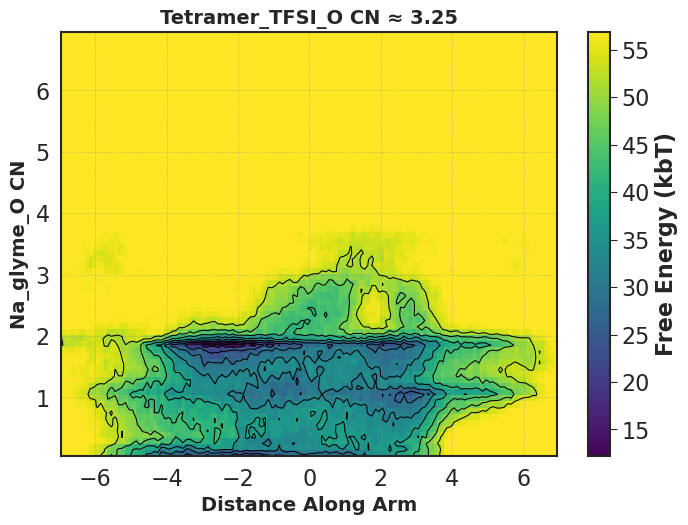

In [11]:
# Explore different fixed indices:
fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
slc_xy, ax_x, ax_y, xl, yl, ts = slice_projection(pmf3d, ux, uy, uz, labels=labels, z_idx=32)
plot_slice(ax, slc_xy, ax_x, ax_y, xlabel=labels["x"], ylabel=labels["y"], title_suffix=ts,n_levels=10)

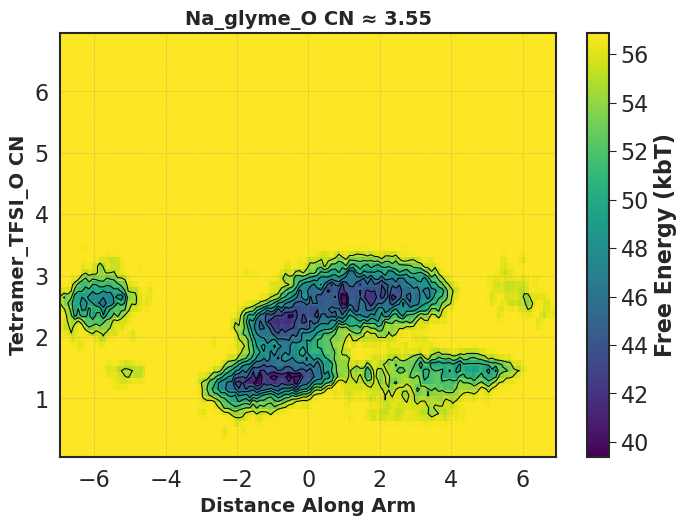

In [21]:
# Explore different fixed indices:
fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
slc_xz, ax_x, ax_z, xl, yl, ts = slice_projection(pmf3d, ux, uy, uz, labels=labels, y_idx=uy.size//2)
plot_slice(ax, slc_xz, ax_x, ax_z, xlabel=labels["x"], ylabel=labels["z"], title_suffix=ts,n_levels=10)

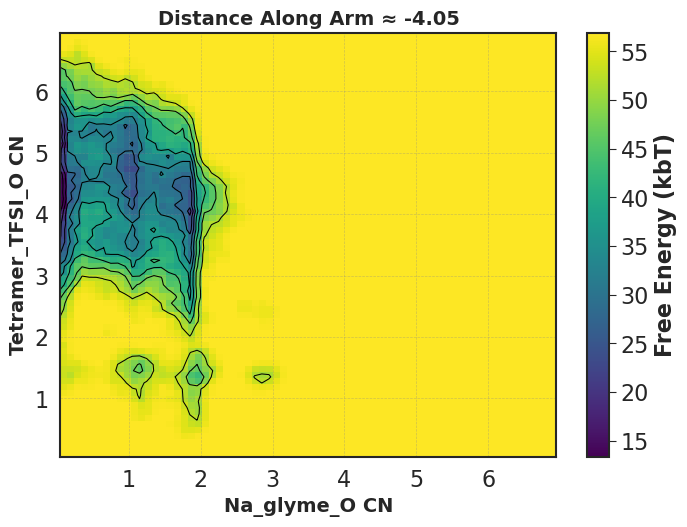

In [23]:
# Explore different fixed indices:
fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
slc_yz, ax_y, ax_z, xl, yl, ts = slice_projection(pmf3d, ux, uy, uz, labels=labels, x_idx=29)
plot_slice(ax, slc_yz, ax_y, ax_z, xlabel=labels["y"], ylabel=labels["z"], title_suffix=ts,n_levels=10)

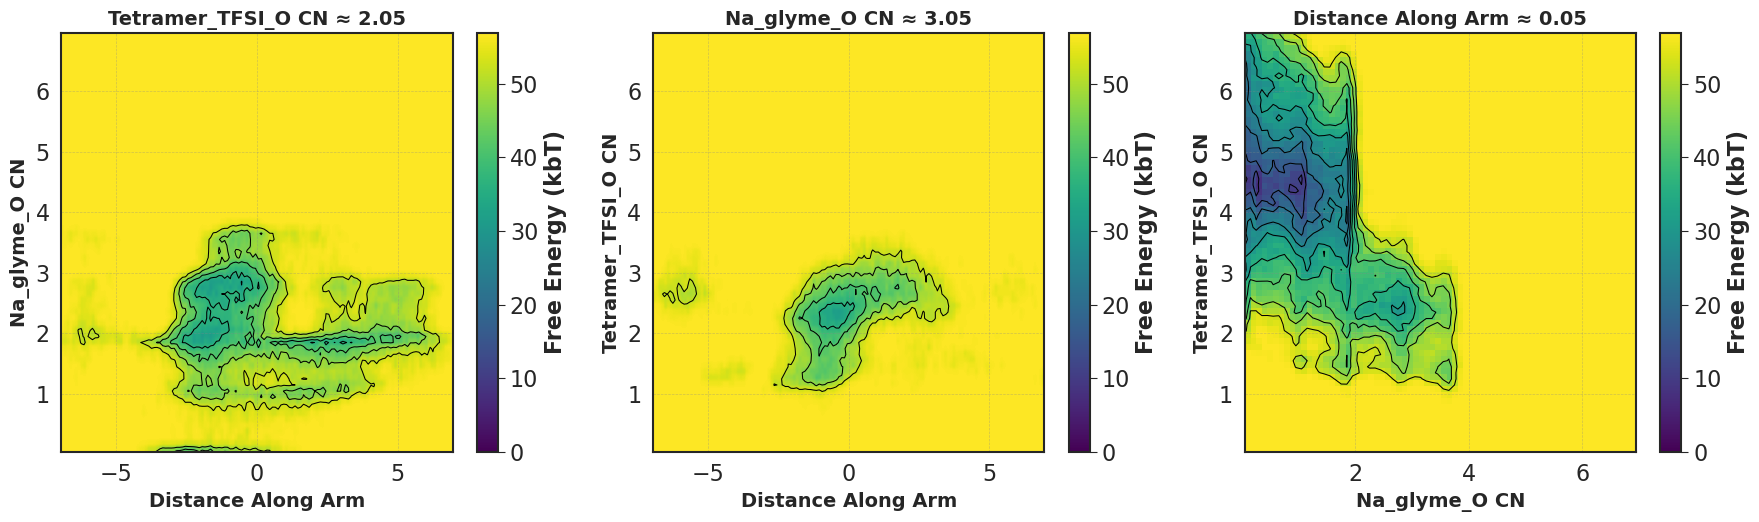

In [30]:

fig, axes = plot_three_projections(
    pmf3d, ux, uy, uz,
    x_idx=70, y_idx=30, z_idx=20,
    labels = {
    "y": "Na_glyme_O CN",
    "z": "Tetramer_TFSI_O CN",
    "x": "Distance Along Arm"
},
    cmap="viridis", contour=True, n_levels=12, share_limits="global"
)
fig.savefig("pmf_projections.png", dpi=300, bbox_inches="tight")


### Find local minimum

In [18]:
import numpy as np
import pandas as pd

def _strict_local_minima_2d(A):
    """
    Return a boolean mask of strict 8-neighborhood minima in 2D array A.
    A pixel is a local minimum if it is strictly lower than all 8 neighbors.
    NaN/inf are excluded.
    """
    A = np.asarray(A)
    finite = np.isfinite(A)
    # pad with +inf so borders can be compared safely
    Ap = np.pad(A, ((1,1),(1,1)), mode='constant', constant_values=np.inf)
    C  = Ap[1:-1, 1:-1]
    neighs = [
        Ap[:-2, :-2], Ap[:-2, 1:-1], Ap[:-2, 2:],
        Ap[1:-1, :-2],               Ap[1:-1, 2:],
        Ap[2:, :-2],  Ap[2:, 1:-1],  Ap[2:, 2:]
    ]
    cond = np.ones_like(A, dtype=bool)
    for N in neighs:
        cond &= (C < N)
    cond &= finite
    return cond

def slice_minima_along_x_zyx(
    pmf3d, ux, uy, uz, *,
    return_all_locals=False
):
    """
    Data-only minima (no smoothing) for pmf3d shaped (nz, ny, nx)=[z,y,x].

    Returns
    -------
    df_global : DataFrame with columns:
        ["x", "Fmin_kbT", "y_at_min", "z_at_min", "ix", "iy", "iz"]
    locals_by_x : list of DataFrames (only if return_all_locals=True)
        Each has ["y","z","F","iy","iz"] for strict 8-neighbor minima on that slice.
    """
    pmf = np.array(pmf3d, copy=True)  # (nz, ny, nx)
    nz, ny, nx = pmf.shape

    # Treat invalid values as forbidden for the min search
    bad = ~np.isfinite(pmf)
    if np.any(bad):
        pmf[bad] = np.inf

    # Vectorized global minima across (z,y) for each x
    flat = pmf.reshape(nz * ny, nx)              # (nz*ny, nx)
    flat_idx = np.argmin(flat, axis=0)           # length nx
    iz = flat_idx // ny                          # unravel z
    iy = flat_idx %  ny                          # unravel y
    Fmin_kbT = pmf[iz, iy, np.arange(nx)]

    df_global = pd.DataFrame({
        "x": ux,
        "Fmin_kbT": Fmin_kbT,
        "y_at_min": uy[iy],
        "z_at_min": uz[iz],
        "ix": np.arange(nx, dtype=int),
        "iy": iy,
        "iz": iz
    })

    if not return_all_locals:
        return df_global

    # Strict local minima per (z,y) slice at each x (no smoothing, no prominence)
    locals_by_x = []
    for ix in range(nx):
        slice_zy = pmf[:, :, ix]                 # (nz, ny)
        cand = _strict_local_minima_2d(slice_zy) # boolean mask
        iz_c, iy_c = np.where(cand)
        F_c = slice_zy[iz_c, iy_c]
        df_loc = pd.DataFrame({
            "y": uy[iy_c],
            "z": uz[iz_c],
            "F": F_c,
            "iy": iy_c,
            "iz": iz_c
        }).sort_values("F", ascending=True, kind="mergesort").reset_index(drop=True)
        locals_by_x.append(df_loc)

    return df_global, locals_by_x

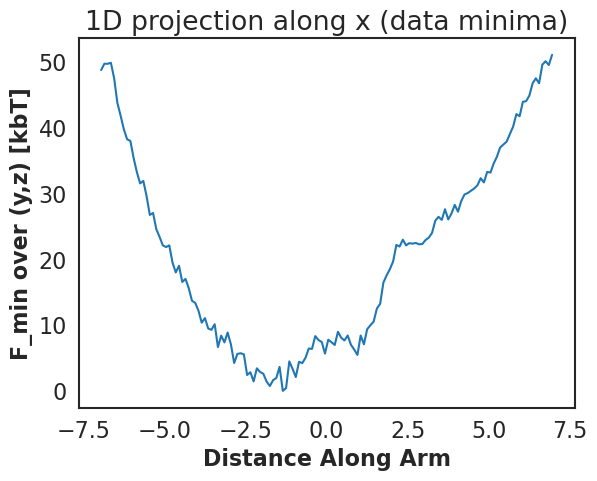

In [19]:
df_global, locals_by_x = slice_minima_along_x_zyx(
    pmf3d, ux, uy, uz, return_all_locals=True
)

# 1D projection: F_min(x)
plt.figure()
plt.plot(df_global["x"], df_global["Fmin_kbT"])
plt.xlabel(labels.get("x","CV1")); plt.ylabel("F_min over (y,z) [kbT]")
plt.title("1D projection along x (data minima)"); plt.show()


In [20]:
df_global.to_csv("local_minima_along_tetramer_arm.csv")

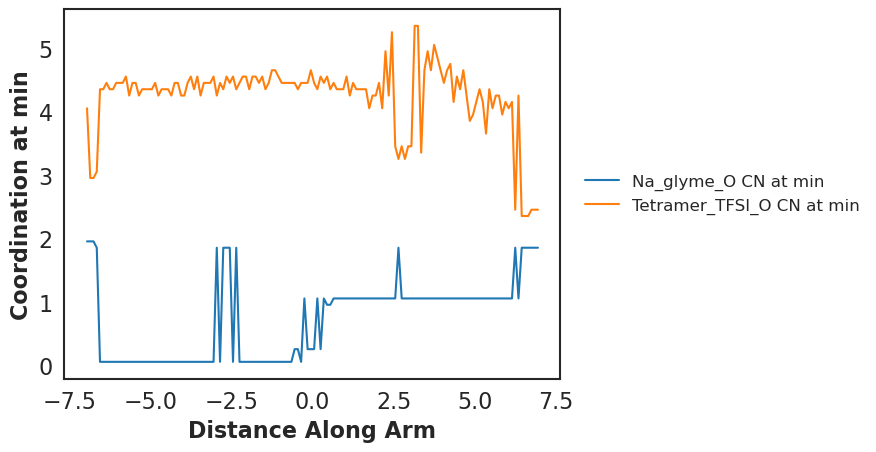

In [21]:
# y*(x), z*(x) at the slice-global minima
plt.figure()
plt.plot(df_global["x"], df_global["y_at_min"], label=f"{labels.get('y','CV2')} at min")
plt.plot(df_global["x"], df_global["z_at_min"], label=f"{labels.get('z','CV3')} at min")
plt.xlabel(labels.get("x","CV1")); plt.ylabel("Coordination at min"); plt.legend(loc="center left",fontsize=12, bbox_to_anchor=(1.02, 0.5), frameon=False); plt.show()